In [19]:
!pip install keras-tcn --quiet

# Import Libraries

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from google.colab import drive

print("Imports done")

Imports done


In [21]:
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: Tesla T4


# Setup

In [ ]:
DATA_DIR          = "/content/drive/MyDrive/ECG_Processed_Final"
X_TRAIN_PATH      = f"{DATA_DIR}/X_train.npy"
Y_TRAIN_PATH      = f"{DATA_DIR}/y_train.npy"
X_TEST_PATH       = f"{DATA_DIR}/X_test.npy"
Y_TEST_PATH       = f"{DATA_DIR}/y_test.npy"

CHECKPOINT_DIR    = f"{DATA_DIR}/transformer_checkpoints"
CHECKPOINT_BEST   = f"{CHECKPOINT_DIR}/best_transformer.pt"
CHECKPOINT_LATEST = f"{CHECKPOINT_DIR}/latest_transformer.pt"
HISTORY_PATH      = f"{CHECKPOINT_DIR}/transformer_history.npy"

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

NUM_CLASSES   = 4
SEQ_LEN       = 4500
BATCH_SIZE    = 64
EPOCHS        = 80
LR            = 3e-4
DROPOUT       = 0.1
PATIENCE      = 20
LABEL_NAMES   = ["Normal (N)", "AF (A)", "Other (O)", "Noisy (~)"]

CLASS_WEIGHTS = {
    0: 0.59,
    1: 2.02,
    2: 0.59,
    3: 7.77,
}

RANDOM_STATE  = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print("Config loaded")

Config loaded


# Load Data

In [ ]:
print("Loading data...")
X_train = np.load(X_TRAIN_PATH) 
y_train = np.load(Y_TRAIN_PATH)
X_test  = np.load(X_TEST_PATH)
y_test  = np.load(Y_TEST_PATH)

X_train = X_train.squeeze(-1).astype(np.float32)
X_test  = X_test.squeeze(-1).astype(np.float32)

print(f"X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}   y_test:  {y_test.shape}")

print("\nClass distribution:")
for i, name in enumerate(LABEL_NAMES):
    print(f"  {name}: train={np.sum(y_train==i)}  test={np.sum(y_test==i)}")

Loading data...
X_train: (22376, 4500)  y_train: (22376,)
X_test:  (5548, 4500)   y_test:  (5548,)

Class distribution:
  Normal (N): train=13028  test=3220
  AF (A): train=1906  test=498
  Other (O): train=6942  test=1696
  Noisy (~): train=500  test=134


# DataLoaders

In [25]:
AUTOTUNE = 2

train_ds = TensorDataset(
    torch.tensor(X_train),
    torch.tensor(y_train, dtype=torch.long)
)
test_ds = TensorDataset(
    torch.tensor(X_test),
    torch.tensor(y_test, dtype=torch.long)
)

train_loader = DataLoader(
    train_ds,
    batch_size  = BATCH_SIZE,
    shuffle     = True,
    num_workers = AUTOTUNE,
    pin_memory  = True
)
test_loader = DataLoader(
    test_ds,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = AUTOTUNE,
    pin_memory  = True
)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches:  {len(test_loader)}")

Train batches: 350
Test batches:  87


# Model Architecture

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=200, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        pe       = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


class ECGTransformer(nn.Module):
    """
    Key changes from previous version:
        patch_size 30  -> 90   reduces seq_len from 150 to 50
                                fewer tokens = attention works better
        d_model    128 -> 256  more representational capacity
        nhead      8   -> 8    each head now has 32 dims instead of 16
        num_layers 4   -> 6    deeper model
        dim_ff     256 -> 512  wider feedforward sublayer
        dropout    0.2 -> 0.1  was underfitting, reduce regularization
    """
    def __init__(
        self,
        seq_len     = SEQ_LEN,
        patch_size  = 90, # 0.3 seconds per patch — one full cardiac cycle component
        d_model     = 256,
        nhead       = 8,
        num_layers  = 6,
        dim_ff      = 512,
        num_classes = NUM_CLASSES,
        dropout     = DROPOUT
    ):
        super().__init__()

        assert seq_len % patch_size == 0, \
            f"seq_len {seq_len} must be divisible by patch_size {patch_size}"

        self.patch_size  = patch_size
        self.num_patches = seq_len // patch_size   # 4500 // 90 = 50 patches

        self.patch_embedding = nn.Sequential(
            nn.Linear(patch_size, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Linear(d_model, d_model),
            nn.LayerNorm(d_model)
        )

        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model) * 0.02)

        self.pos_encoding = PositionalEncoding(
            d_model = d_model,
            max_len = self.num_patches + 1,
            dropout = dropout
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model         = d_model,
            nhead           = nhead,
            dim_feedforward = dim_ff,
            dropout         = dropout,
            activation      = "gelu",
            batch_first     = True,
            norm_first      = True
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers = num_layers,
            norm       = nn.LayerNorm(d_model)
        )

        self.classifier = nn.Sequential(
            nn.Linear(d_model, 128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

        self._init_weights()

    def _init_weights(self):
        """
        Proper weight initialization for Transformers.
        Without this, deep Transformers can fail to train entirely.
        """
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.trunc_normal_(module.weight, std=0.02)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)
            elif isinstance(module, nn.LayerNorm):
                nn.init.ones_(module.weight)
                nn.init.zeros_(module.bias)

    def forward(self, x):
        batch_size = x.size(0)

        x = x.view(batch_size, self.num_patches, self.patch_size)

        x = self.patch_embedding(x)

        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        x = torch.cat([cls_tokens, x], dim=1)

        x = self.pos_encoding(x)

        x = self.transformer(x)

        cls_output = x[:, 0, :]

        return self.classifier(cls_output)


model = ECGTransformer().to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model: ECGTransformer (improved)")
print(f"Patch size:        {model.patch_size} samples = {model.patch_size/300*1000:.0f}ms")
print(f"Number of patches: {model.num_patches}")
print(f"d_model:           256")
print(f"Trainable params:  {total_params:,}")

Model: ECGTransformer (improved)
Patch size:        90 samples = 300ms
Number of patches: 50
d_model:           256
Trainable params:  3,286,916


/tmp/ipykernel_2035/446196651.py:79: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


# Loss, Optimizer, Scheduler

In [ ]:
weights_tensor = torch.tensor(
    list(CLASS_WEIGHTS.values()), dtype=torch.float32
).to(device)

criterion = nn.CrossEntropyLoss(
    weight          = weights_tensor,
    label_smoothing = 0.1
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr = LR,
    weight_decay = 1e-3,
    betas = (0.9, 0.999)
)

def lr_lambda(epoch):
    warmup_epochs = 5
    if epoch < warmup_epochs:
        return (epoch + 1) / warmup_epochs
    progress = (epoch - warmup_epochs) / max(1, EPOCHS - warmup_epochs)
    return 0.5 * (1.0 + np.cos(np.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

print("Loss, optimizer, scheduler ready")
print(f"Initial LR: {LR}")

Loss, optimizer, scheduler ready
Initial LR: 0.0003


# Training Functions

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss   = criterion(logits, y_batch)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        total_loss += loss.item() * len(y_batch)
        correct    += (logits.argmax(dim=1) == y_batch).sum().item()
        total      += len(y_batch)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_targets = [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)

            logits = model(X_batch)
            loss   = criterion(logits, y_batch)

            total_loss += loss.item() * len(y_batch)
            correct    += (logits.argmax(dim=1) == y_batch).sum().item()
            total      += len(y_batch)
            all_preds.extend(logits.argmax(dim=1).cpu().numpy())
            all_targets.extend(y_batch.cpu().numpy())

    return (total_loss / total, correct / total,
            np.array(all_preds), np.array(all_targets))

print("Training functions ready")

Training functions ready


#  Load Checkpoint (if any)

In [ ]:
start_epoch = 0
best_val_loss = float("inf")
patience_counter = 0
PATIENCE = 15
history = {"train_loss": [], "val_loss": [],
           "train_acc":  [], "val_acc":  [],
           "lr": []}

if os.path.exists(CHECKPOINT_LATEST):
    ckpt = torch.load(CHECKPOINT_LATEST, map_location=device)
    model.load_state_dict(ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optimizer_state"])
    scheduler.load_state_dict(ckpt["scheduler_state"])
    start_epoch      = ckpt["epoch"] + 1
    best_val_loss    = ckpt["best_val_loss"]
    patience_counter = ckpt.get("patience_counter", 0)
    print(f"Resumed from epoch {start_epoch}")
    print(f"Best val loss: {best_val_loss:.4f}")
else:
    print("No checkpoint found, starting fresh")

if os.path.exists(HISTORY_PATH):
    history = np.load(HISTORY_PATH, allow_pickle=True).item()
    print(f"History loaded: {len(history['train_loss'])} epochs done")

print(f"Epochs remaining: {EPOCHS - start_epoch}")

No checkpoint found, starting fresh
Epochs remaining: 80


In [ ]:
weights_tensor = torch.tensor(
    list(CLASS_WEIGHTS.values()), dtype=torch.float32
).to(device)

criterion = nn.CrossEntropyLoss(
    weight          = weights_tensor,
    label_smoothing = 0.1
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr           = LR,
    weight_decay = 1e-2,
    betas        = (0.9, 0.999)
)

def lr_lambda(epoch):
    warmup_epochs = 10
    flat_epochs   = 30
    decay_start   = warmup_epochs + flat_epochs

    if epoch < warmup_epochs:
        return (epoch + 1) / warmup_epochs
    elif epoch < decay_start:
        return 1.0
    else:
        progress = (epoch - decay_start) / max(1, EPOCHS - decay_start)
        return max(0.05, 0.5 * (1.0 + np.cos(np.pi * progress)))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

print("Loss, optimizer, scheduler ready")
print(f"Peak LR:       {LR}")
print(f"Warmup epochs: 10")
print(f"Flat epochs:   30 (epochs 10-40)")
print(f"Decay epochs:  40 (epochs 40-80)")

Loss, optimizer, scheduler ready
Peak LR:       0.0003
Warmup epochs: 10
Flat epochs:   30 (epochs 10-40)
Decay epochs:  40 (epochs 40-80)


# Train

In [ ]:
if start_epoch >= EPOCHS:
    print("Training complete. Run evaluation cell.")
else:
    print(f"Training from epoch {start_epoch + 1} to {EPOCHS}")
    print("=" * 75)

    for epoch in range(start_epoch, EPOCHS):
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device
        )
        val_loss, val_acc, _, _ = evaluate(
            model, test_loader, criterion, device
        )

        current_lr = optimizer.param_groups[0]["lr"]
        scheduler.step()
        new_lr = optimizer.param_groups[0]["lr"]

        if new_lr != current_lr:
            print(f"  >>> LR changed: {current_lr:.2e} → {new_lr:.2e}")

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["lr"].append(current_lr)

        print(f"Epoch {epoch+1:>3}/{EPOCHS}  "
              f"LR: {current_lr:.2e}  "
              f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f}  "
              f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f}  "
              f"Patience: {patience_counter}/{PATIENCE}")

        torch.save({
            "epoch":            epoch,
            "model_state":      model.state_dict(),
            "optimizer_state":  optimizer.state_dict(),
            "scheduler_state":  scheduler.state_dict(),
            "best_val_loss":    best_val_loss,
            "patience_counter": patience_counter,
        }, CHECKPOINT_LATEST)

        if val_loss < best_val_loss:
            best_val_loss    = val_loss
            patience_counter = 0
            torch.save({
                "epoch":        epoch,
                "model_state":  model.state_dict(),
                "best_val_loss": best_val_loss,
            }, CHECKPOINT_BEST)
            print(f"  >>> Best model saved (epoch {epoch + 1})")
        else:
            patience_counter += 1

        np.save(HISTORY_PATH, history)

        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch + 1}")
            break

    print("\nTraining complete")

Training from epoch 1 to 80
  >>> LR changed: 3.00e-05 → 6.00e-05
Epoch   1/80  LR: 3.00e-05  Train Loss: 1.1865  Acc: 0.7302  Val Loss: 1.4145  Acc: 0.6763  Patience: 0/15
  >>> Best model saved (epoch 1)
  >>> LR changed: 6.00e-05 → 9.00e-05
Epoch   2/80  LR: 6.00e-05  Train Loss: 1.1657  Acc: 0.7474  Val Loss: 1.4198  Acc: 0.6757  Patience: 0/15
  >>> LR changed: 9.00e-05 → 1.20e-04
Epoch   3/80  LR: 9.00e-05  Train Loss: 1.1630  Acc: 0.7491  Val Loss: 1.4380  Acc: 0.6729  Patience: 1/15
  >>> LR changed: 1.20e-04 → 1.50e-04
Epoch   4/80  LR: 1.20e-04  Train Loss: 1.1700  Acc: 0.7471  Val Loss: 1.4356  Acc: 0.6629  Patience: 2/15
  >>> LR changed: 1.50e-04 → 1.80e-04
Epoch   5/80  LR: 1.50e-04  Train Loss: 1.1709  Acc: 0.7461  Val Loss: 1.4399  Acc: 0.6678  Patience: 3/15
  >>> LR changed: 1.80e-04 → 2.10e-04
Epoch   6/80  LR: 1.80e-04  Train Loss: 1.1767  Acc: 0.7410  Val Loss: 1.4769  Acc: 0.6592  Patience: 4/15
  >>> LR changed: 2.10e-04 → 2.40e-04
Epoch   7/80  LR: 2.10e-04  Tra

# Evaluate Best Model

In [41]:
ckpt = torch.load(CHECKPOINT_BEST, map_location=device)
model.load_state_dict(ckpt["model_state"])
print(f"Loaded best model from epoch {ckpt['epoch'] + 1}")

_, _, y_pred, y_true = evaluate(model, test_loader, criterion, device)

acc = accuracy_score(y_true, y_pred)
print(f"\nTest Accuracy: {acc:.4f}  ({acc * 100:.2f}%)")
print("\nClassification Report:")
print(classification_report(y_true, y_pred,
      target_names=LABEL_NAMES, digits=4))

Loaded best model from epoch 12

Test Accuracy: 0.6802  (68.02%)

Classification Report:
              precision    recall  f1-score   support

  Normal (N)     0.7689    0.7997    0.7840      3220
      AF (A)     0.5000    0.6647    0.5707       498
   Other (O)     0.5923    0.4634    0.5200      1696
   Noisy (~)     0.3905    0.6119    0.4767       134

    accuracy                         0.6802      5548
   macro avg     0.5629    0.6349    0.5879      5548
weighted avg     0.6816    0.6802    0.6767      5548



# Training Curves

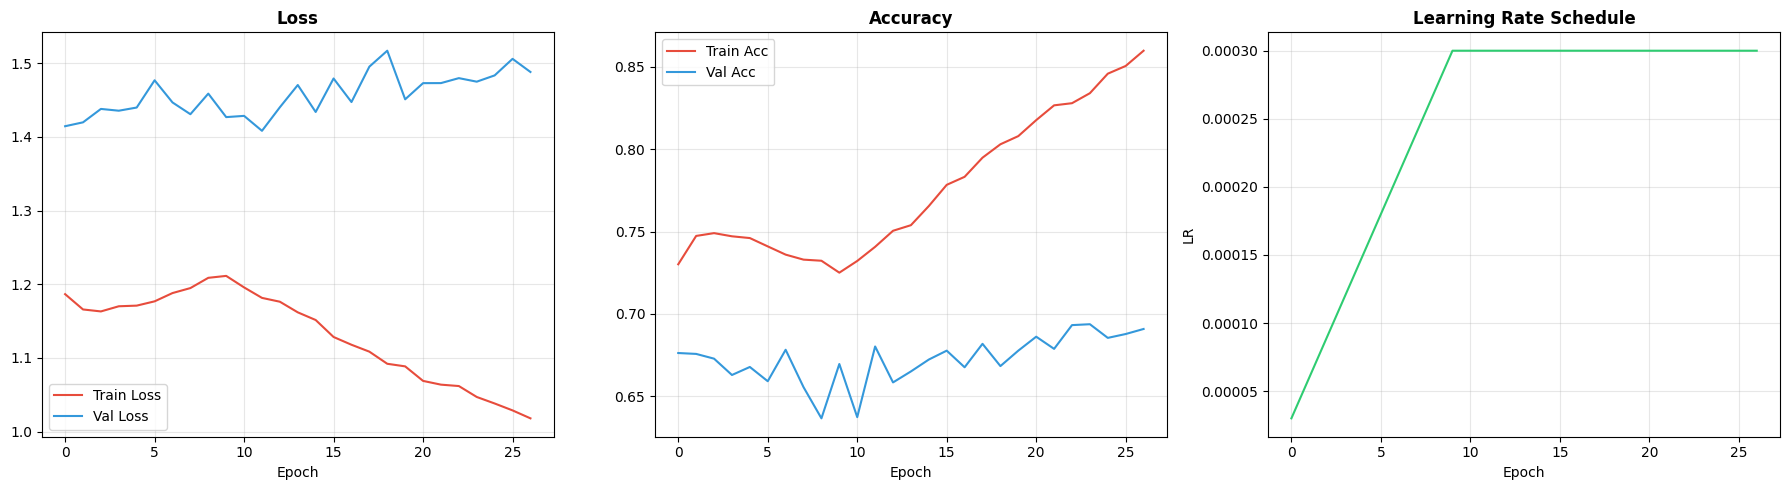

Best val accuracy: 0.6938


In [42]:
h   = np.load(HISTORY_PATH, allow_pickle=True).item()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(h["train_loss"], label="Train Loss", color="#e74c3c", linewidth=1.5)
axes[0].plot(h["val_loss"],   label="Val Loss",   color="#3498db", linewidth=1.5)
axes[0].set_title("Loss", fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(h["train_acc"], label="Train Acc", color="#e74c3c", linewidth=1.5)
axes[1].plot(h["val_acc"],   label="Val Acc",   color="#3498db", linewidth=1.5)
axes[1].set_title("Accuracy", fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(h["lr"], color="#2ecc71", linewidth=1.5)
axes[2].set_title("Learning Rate Schedule", fontweight="bold")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("LR")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{CHECKPOINT_DIR}/transformer_training_curves.png",
            dpi=150, bbox_inches="tight")
plt.show()
print(f"Best val accuracy: {max(h['val_acc']):.4f}")

# Confusion Matrix

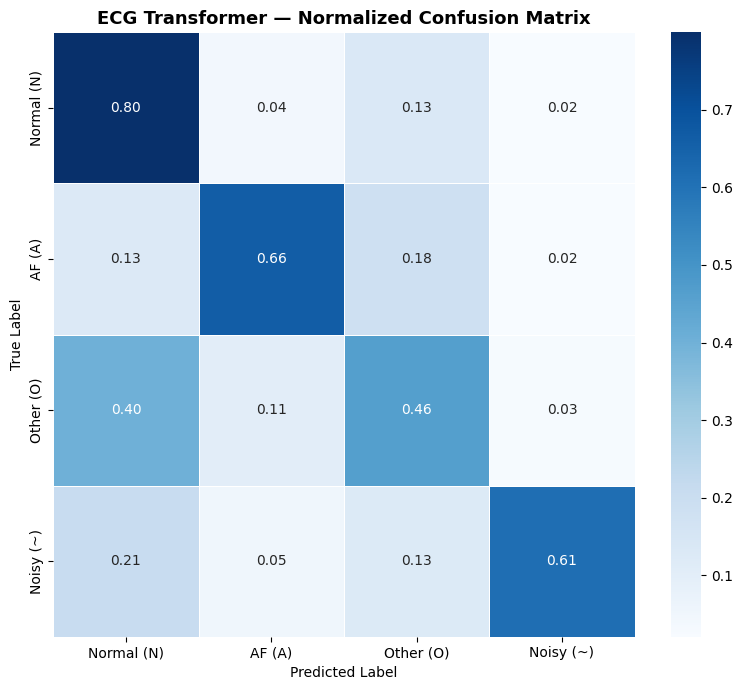

In [43]:
cm  = confusion_matrix(y_true, y_pred, normalize="true")
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
            linewidths=0.5, ax=ax)
ax.set_title("ECG Transformer — Normalized Confusion Matrix",
             fontsize=13, fontweight="bold")
ax.set_ylabel("True Label")
ax.set_xlabel("Predicted Label")
plt.tight_layout()
plt.savefig(f"{CHECKPOINT_DIR}/transformer_confusion_matrix.png",
            dpi=150, bbox_inches="tight")
plt.show()